# Multi-Model Forecasting of Amazon (AMZN) Stock Prices
Predicting Amazon (AMZN) stock prices through multiple ML models, from baseline regressions to ensemble methods.

### Key Objectives:
* **Feature Engineering:** Implementation of technical indicators (MACD, RSI, Bollinger Bands) and time-lag features.
* **Algorithm Comparison:** Evaluation of multiple models including a custom Linear Regression from scratch, Random Forest, XGBoost, and SVR.
* **Real-world Validation:** Testing performance on a specific 2025 time window to assess generalization.

In [1]:
import os
import warnings
from datetime import datetime

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot') # fallback if seaborn style is missing

plt.rcParams['figure.figsize'] = [16, 7]
plt.rcParams['figure.dpi'] = 100

# MACHINE LEARNING & FINANCIAL LIBRARIES
# financial data API
try:
    import yfinance as yf
except ImportError:
    print("ERROR: 'yfinance' not found. RUN: pip install yfinance")

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, TimeSeriesSplit)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
from scipy.stats import uniform, randint

# advanced models
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ENVIRONMENT & REPRODUCIBILITY
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

# DIRECTORY SETTINGS
save_path = "outputs"
if not os.path.exists(save_path):
    os.makedirs(save_path)

print(f"Environment configured successfully.")
print(f"Results will be saved LOCALLY at: {os.path.abspath(save_path)}")

/Users/gabo/Desktop/stock_prices/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Environment configured successfully.
Results will be saved LOCALLY at: /Users/gabo/Desktop/stock_prices/outputs


In [2]:
# in case of error, run it again

# timeframe
start_date = "2015-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")
train_end_date = "2025-08-31"

print(f"Data Range: {start_date} to {end_date}")
print(f"Train/Test Cut-off: {train_end_date}")

# List of tech stocks to download
tickers = ["AMZN", "MSFT", "GOOG", "META", "AAPL"]

# DATA DOWNLOAD --> stokcs & indices

print(f"Fetching stock data for: {', '.join(tickers)}...")
stocks = yf.download(tickers, start=start_date, end=end_date, progress=False)

if isinstance(stocks.columns, pd.MultiIndex):
    stocks = stocks['Close']

stocks = stocks.rename(columns={
    "AMZN": "Amazon",
    "MSFT": "Microsoft",
    "GOOG": "Google",
    "META": "Meta",
    "AAPL": "Apple"
})

print("Fetching market indices (^GSPC, ^DJI)...")

# S&P 500 Index
sp500 = yf.download("^GSPC", start=start_date, end=end_date, progress=False)['Close']
sp500 = sp500.squeeze()
sp500.name = "S&P500"

# Dow Jones Industrial Average
dowjones = yf.download("^DJI", start=start_date, end=end_date, progress=False)['Close']
dowjones = dowjones.squeeze()
dowjones.name = "DowJones"

# DATA CONSOLIDATION & FEATURE CREATION

# Merging all assets into a single DataFrame --> using inner join
dataset = stocks.join([sp500, dowjones], how='inner')

# time-based features (Cyclical components)
dataset["Year"] = dataset.index.year
dataset["Month"] = dataset.index.month
dataset["Day"] = dataset.index.day
dataset["Weekday"] = dataset.index.weekday

# saving raw dataset locally
output_file = os.path.join(save_path, "dataset_base.csv")
dataset.to_csv(output_file)

print(f"\nBase dataset saved at: {output_file}")
print(f"Total trading days downloaded: {len(dataset)}")
print(f"Period covered: {dataset.index.min().date()} to {dataset.index.max().date()}")

Data Range: 2015-01-01 to 2026-03-22
Train/Test Cut-off: 2025-08-31
Fetching stock data for: AMZN, MSFT, GOOG, META, AAPL...
Fetching market indices (^GSPC, ^DJI)...

Base dataset saved at: outputs/dataset_base.csv
Total trading days downloaded: 2820
Period covered: 2015-01-02 to 2026-03-20


# Historical Price Visualization

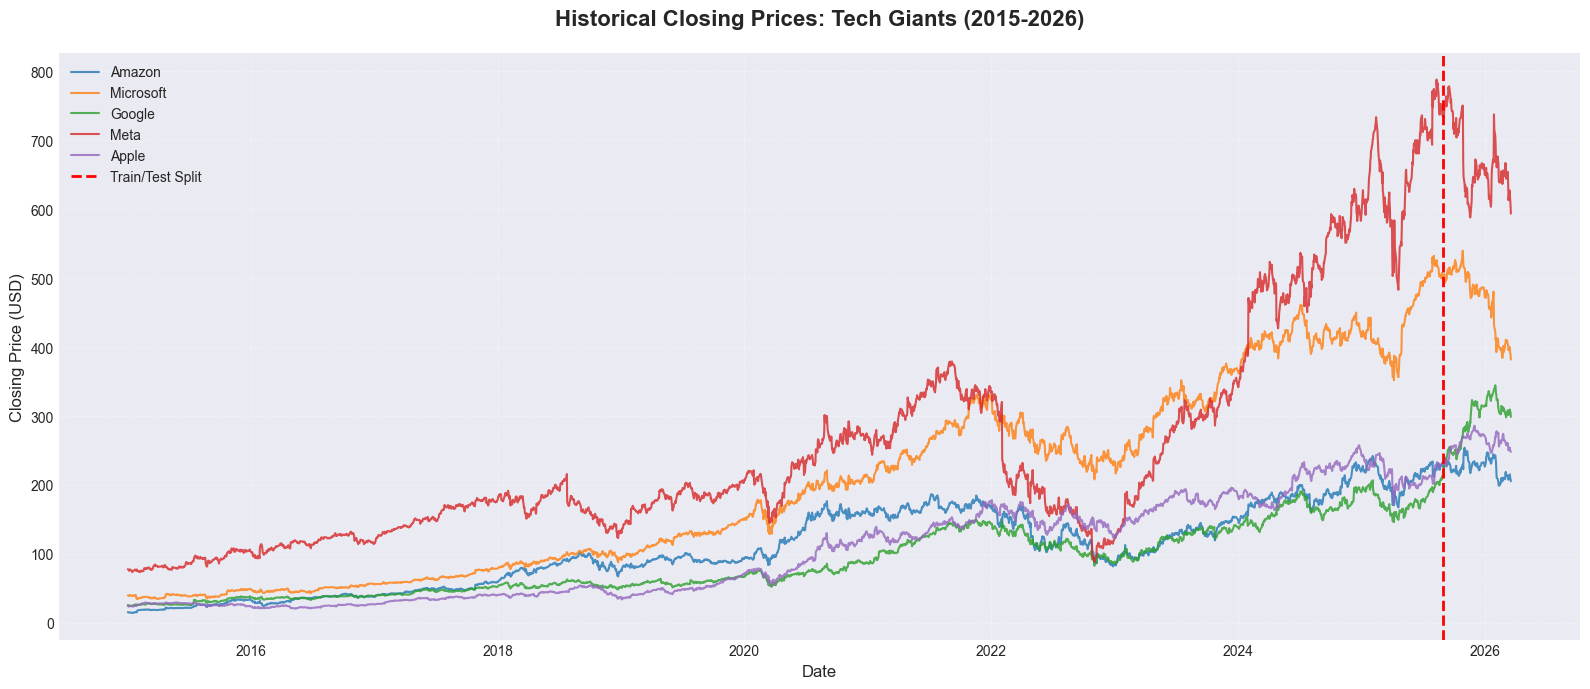

In [3]:
plt.figure(figsize=(16, 7))

assets_to_plot = ["Amazon", "Microsoft", "Google", "Meta", "Apple"]

for col in assets_to_plot:
    if col in dataset.columns:
        plt.plot(dataset.index, dataset[col], label=col, linewidth=1.5, alpha=0.8)

plt.axvline(x=pd.to_datetime(train_end_date), color='red', linestyle='--', linewidth=2, label='Train/Test Split')

# chart
plt.title("Historical Closing Prices: Tech Giants (2015-2026)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (USD)", fontsize=12)
plt.legend(loc='upper left', fontsize=10, framealpha=0.95, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA): Market Correlations
We analyze the relationship between different tech stocks and market indices. High correlation between assets suggests they move in tandem, which is a critical insight for multivariate forecasting.

Displaying the last 5 records for data integrity check:


,Apple,Amazon,Google,Meta,Microsoft,S&P500,DowJones,Year,Month,Day,Weekday
Date,,,,,,,,,,,
2026-03-16,252.820007,211.740005,304.420013,627.450012,399.950012,6699.379883,46946.410156,2026,3,16,0
2026-03-17,254.229996,215.199997,309.410004,622.659973,399.410004,6716.089844,46993.261719,2026,3,17,1
2026-03-18,249.940002,209.869995,306.299988,615.679993,391.790009,6624.700195,46225.148438,2026,3,18,2
2026-03-19,248.960007,208.759995,305.730011,606.700012,389.019989,6606.490234,46021.429688,2026,3,19,3
2026-03-20,247.990005,205.369995,298.790009,593.659973,381.850006,6506.479980,45577.468750,2026,3,20,4


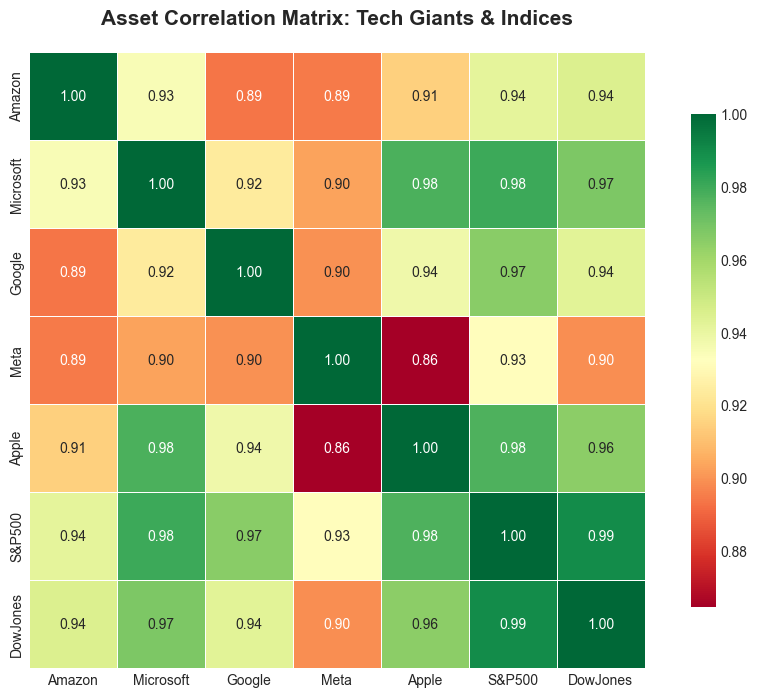

In [4]:
# verification
print("Displaying the last 5 records for data integrity check:")
display(dataset.tail())

# visualizing market correlations
try:
    import seaborn as sns
    core_assets = ["Amazon", "Microsoft", "Google", "Meta", "Apple", "S&P500", "DowJones"]
    correlation_matrix = dataset[core_assets].corr()

    plt.figure(figsize=(12, 8))
    
    sns.heatmap(correlation_matrix, 
                annot=True, 
                cmap='RdYlGn', 
                fmt=".2f", 
                linewidths=0.5,
                square=True,
                cbar_kws={"shrink": .8})

    plt.title("Asset Correlation Matrix: Tech Giants & Indices", fontsize=15, fontweight='bold', pad=20)
    plt.show()

except ImportError:
    print("ERROR: 'seaborn' library not found. RUN: 'pip install seaborn' in your terminal.")

### Feature Engineering: Technical Indicators
New features are engineered to capture market trends, price momentum, and volatility. These indicators provide the model with a deeper context beyond raw closing prices.

#### Calculated Columns per Asset:

* **`{col}_Return`**: Measures the **daily percentage change**. It indicates price direction and magnitude relative to the previous day.
* **`{col}_SMA7` & `{col}_SMA30`**: **Simple Moving Averages** for 7 and 30 days. These smooth out price fluctuations to identify short and medium-term trends.
* **`{col}_EMA12` & `{col}_EMA26`**: **Exponential Moving Averages** that assign more weight to recent data, reacting faster to price reversals.
* **`{col}_MACD`**: **Moving Average Convergence Divergence**, calculated as the difference between the 12-day and 26-day EMAs. It helps detect changes in trend strength and direction.
* **`{col}_Signal`**: The **Signal Line** (9-day EMA of the MACD). Used alongside the MACD to generate potential buy/sell triggers.
* **`{col}_RSI`**: **Relative Strength Index**, a momentum oscillator that measures the speed and change of price movements. Values above 70 indicate **overbought** conditions, while values below 30 suggest **oversold** levels.
* **`{col}_Volatility`**: Measures price instability using the **14-day standard deviation** of returns. High volatility represents higher risk and larger price swings.

#### General Market Features:

* **`EndOfMonth`**: A binary flag (`1` = Yes, `0` = No) to capture periodic market patterns often seen during financial reporting cycles.
* **`Market_Spread`**: Calculated as the daily difference between the **S&P 500** and the **Dow Jones**. It allows the model to compare the relative behavior of these two major benchmarks.

In [5]:
target_assets = ["Amazon", "Microsoft", "Google", "Meta", "Apple"]

for col in target_assets:
    # percentage returns (Volatility and Magnitude)
    dataset[f"{col}_Return"] = dataset[col].pct_change()

    # simple moving averages (SMA) - trend identification
    dataset[f"{col}_SMA7"] = dataset[col].rolling(window=7).mean()
    dataset[f"{col}_SMA30"] = dataset[col].rolling(window=30).mean()

    # exponential moving averages (EMA) --> faster trend reaction
    dataset[f"{col}_EMA12"] = dataset[col].ewm(span=12, adjust=False).mean()
    dataset[f"{col}_EMA26"] = dataset[col].ewm(span=26, adjust=False).mean()

    # moving average covergece divergence (MACD)
    dataset[f"{col}_MACD"] = dataset[f"{col}_EMA12"] - dataset[f"{col}_EMA26"]
    dataset[f"{col}_Signal"] = dataset[f"{col}_MACD"].ewm(span=9, adjust=False).mean()

    # relative strength index (RSI) --> Overbought/Oversold Oscillator
    delta = dataset[col].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    dataset[f"{col}_RSI"] = 100 - (100 / (1 + rs))

    # volatility --> Risk Measurement
    dataset[f"{col}_Volatility"] = dataset[f"{col}_Return"].rolling(window=14).std()

    # Bollinger Bands (Price Range and Volatility)
    # standard deviation once for efficiency
    std30 = dataset[col].rolling(30).std()
    dataset[f"{col}_BB_upper"] = dataset[f"{col}_SMA30"] + (2 * std30)
    dataset[f"{col}_BB_lower"] = dataset[f"{col}_SMA30"] - (2 * std30)

    # momentum --> price strength over 10 Days
    dataset[f"{col}_Momentum"] = dataset[col] - dataset[col].shift(10)

# GENERAL MARKET INDICATORS

# end of month binary flag
dataset["Is_Month_End"] = dataset.index.is_month_end.astype(int)

# market sentiment spread (S&P 500 vs Dow Jones)
dataset["Market_Spread"] = dataset["S&P500"] - dataset["DowJones"]

print("\nTechnical indicators successfully calculated.")
print(f"Total features in dataset: {dataset.shape[1]}")


Technical indicators successfully calculated.
Total features in dataset: 73


### Time-Series Transformation: Lagged Features
Lagging features allows the model to look back at historical data to predict future movements. We use specific intervals to capture different market behaviors:

* **1 Day**: Captures **immediate effects** and daily momentum.
* **3 & 5 Days**: Capture **weekly micro-trends** and short-term reversals.
* **10 & 15 Days**: Capture **medium-term movements** and established trends.
* **30 Days**: Captures **monthly trends** and seasonal market cycles.

In [6]:
# versions of specified columns to capture historical price movements ar differents time horizons
def create_lags(df, columns, lags=[1, 3, 5, 10, 15, 30]):
    for col in columns:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)
    return df

cols_lag = ["Amazon", "Microsoft", "Google", "Meta", "Apple", "S&P500", "DowJones"]

print(f"Generating lags for: {', '.join(cols_lag)}")
print(f"Selected horizons: 1, 3, 5, 10, 15, and 30 trading days.")

# transformation
dataset = create_lags(dataset, cols_lag)

print(f"\nDataset with lagged features successfully created.")
print(f"Total features (columns): {dataset.shape[1]}")

# saving
output_file = os.path.join(save_path, "dataset_enriched.csv")
dataset.to_csv(output_file)
print(f"ENRICHED dataset saved at: {output_file}")

Generating lags for: Amazon, Microsoft, Google, Meta, Apple, S&P500, DowJones
Selected horizons: 1, 3, 5, 10, 15, and 30 trading days.

Dataset with lagged features successfully created.
Total features (columns): 115
ENRICHED dataset saved at: outputs/dataset_enriched.csv


## Algorithm Selection & Model Overview

### 1. Multivariate Linear Regression
Our **baseline model** that assumes a linear relationship between the independent variables (lags, technical indicators) and the target variable (Amazon's stock price). We will implement this using both a custom Gradient Descent approach and scikit-learn for benchmarking.

* **Pros:** Highly interpretable, serves as a solid performance benchmark, and features fast training times.
* **Cons:** Cannot capture non-linear relationships; highly sensitive to outliers and multicollinearity.

### 2. Random Forest Regressor
An **ensemble learning** method based on a collection of decision trees. Each tree learns a different pattern from the data, and the final output is the average of all individual tree predictions.

* **Pros:** Effectively captures non-linear relationships, robust to noise, and handles correlated features well with minimal tuning.
* **Cons:** Risk of overfitting with excessive trees; it does not explicitly account for temporal sequences.

### 3. XGBoost Regressor
A high-performance **Gradient Boosting** model frequently used in financial forecasting and Kaggle competitions. It builds trees sequentially, with each new tree correcting the errors of the previous one.

* **Pros:** Superior accuracy, built-in regularization to prevent overfitting, and automatic handling of missing data.
* **Cons:** Requires precise hyperparameter tuning; does not explicitly model time-series dependencies.

### 4. Support Vector Regressor (SVR)
Based on the principle of **margin maximization**, SVR seeks a hyperplane that fits the data within a specified margin of tolerance (epsilon).

* **Pros:** Highly effective for non-linear data through the "kernel trick"; performs well even on smaller datasets.
* **Cons:** Does not scale efficiently to very large datasets; difficult to tune parameters such as the kernel, C, and epsilon.

In [7]:
# DATA PREPARATION: TARGET DEFINITION & SPLITTING

dataset["Target"] = dataset["Amazon"].shift(-1)

print(f"Target created: Predicting AMZN price for the NEXT day")
print(f"Records before cleaning NaNs: {len(dataset)}")

# no NaN values
dataset_clean = dataset.dropna().copy()

print(f"Records after cleaning NaNs: {len(dataset_clean)}")
print(f"Final date range: {dataset_clean.index.min().date()} to {dataset_clean.index.max().date()}")

train = dataset_clean[dataset_clean.index <= train_end_date].copy()
test = dataset_clean[dataset_clean.index > train_end_date].copy()

print(f"\nTRAIN/TEST SPLIT:")
print(f"  Train: {train.index.min().date()} to {train.index.max().date()} ({len(train)} records)")
print(f"  Test:  {test.index.min().date()} to {test.index.max().date()} ({len(test)} records)")

if len(test) == 0:
    raise ValueError("ERROR: Test set is empty. Check your date range or cutoff settings.")

X_train = train.drop(columns=["Target"])
X_test = test.drop(columns=["Target"])

y_train = train["Target"].values
y_test = test["Target"].values

print(f"\nDATA SHAPES:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  Total features used: {X_train.shape[1]}")

Target created: Predicting AMZN price for the NEXT day
Records before cleaning NaNs: 2820
Records after cleaning NaNs: 2789
Final date range: 2015-02-17 to 2026-03-19

TRAIN/TEST SPLIT:
  Train: 2015-02-17 to 2025-08-29 (2651 records)
  Test:  2025-09-02 to 2026-03-19 (138 records)

DATA SHAPES:
  X_train: (2651, 115)
  X_test:  (138, 115)
  Total features used: 115


In [8]:
# standardScaler normalization
scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)

print("Normalization completed")

# FEATURE SCALING (Standardization)

scaler_standard = StandardScaler()
X_train_scaled = scaler_standard.fit_transform(X_train)
X_test_scaled = scaler_standard.transform(X_test)

print("Feature scaling completed successfully.")
print(f"Scaled X_train shape: {X_train_scaled.shape}")
print(f"Scaled X_test shape:  {X_test_scaled.shape}")


Normalization completed
Feature scaling completed successfully.
Scaled X_train shape: (2651, 115)
Scaled X_test shape:  (138, 115)


In [9]:
# PERFORMANCE METRICS FUNCTION
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # penalizes larger outliers
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred) # percentage of variance explained by the model

    print(f"\n {model_name} Results:")
    print(f"   - MAE:   ${mae:.2f}")
    print(f"   - RMSE:  ${rmse:.2f}")
    print(f"   - MAPE:  {mape:.2f}%")
    print(f"   - R²:    {r2:.4f}\n")

    return {"mae": mae, "rmse": rmse, "mape": mape, "r2": r2}

## Linear Regression: Custom Implementation (Gradient Descent)

Custom implementation of Multivariate Linear Regression to explore the underlying optimization logic without library abstractions.

Training process started:

Iteration    0 | Cost (MSE): 15,343.9764
Iteration  100 | Cost (MSE): 1,627.8451
Iteration  200 | Cost (MSE): 226.8287
Iteration  300 | Cost (MSE): 38.6177
Iteration  400 | Cost (MSE): 12.9277
Iteration  500 | Cost (MSE): 9.1895
Iteration  600 | Cost (MSE): 8.4972
Iteration  700 | Cost (MSE): 8.2751
Iteration  800 | Cost (MSE): 8.1539
Iteration  900 | Cost (MSE): 8.0701
Final Iteration 1000 | Cost: 8.0073

 Custom LR (Gradient Descent) Results:
   - MAE:   $4.02
   - RMSE:  $5.15
   - MAPE:  1.77%
   - R²:    0.8255


Custom LR (GD) Results:
 MAE : 4.0158
 RMSE: 5.1550
 R²  : 0.8255



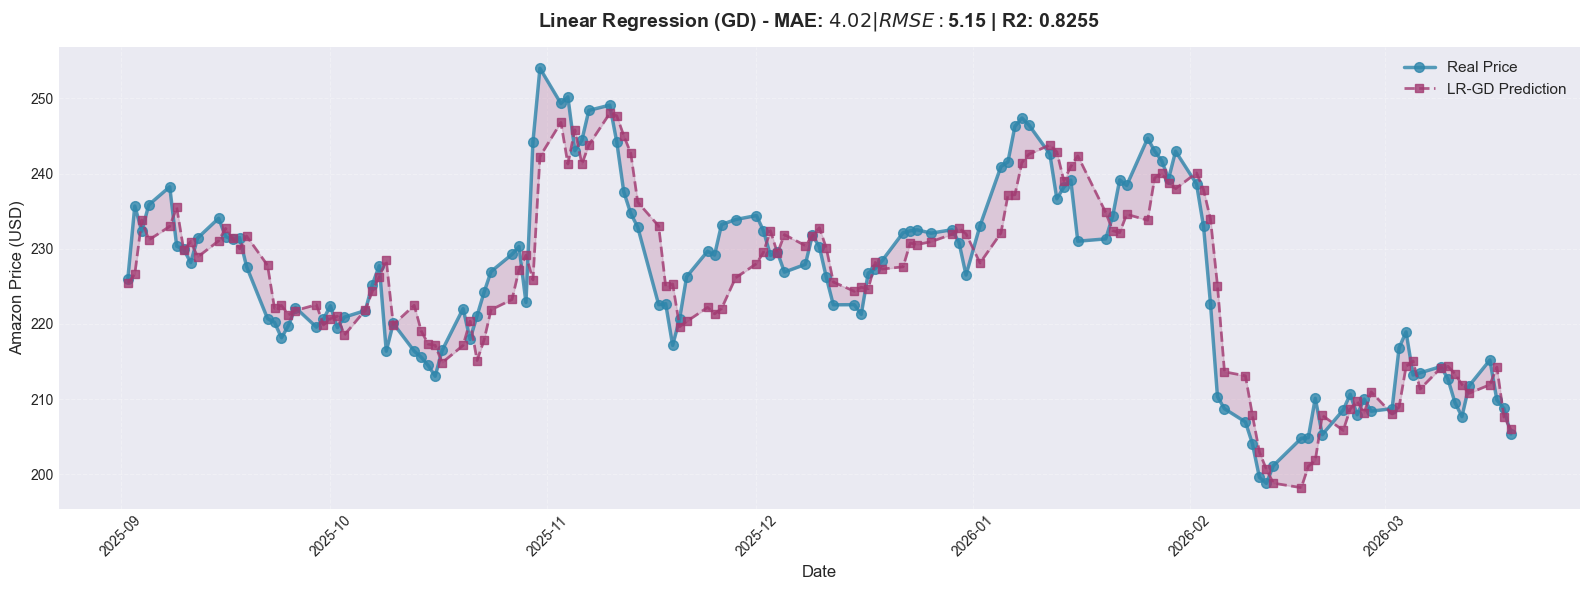

In [10]:
def compute_cost(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def predict(X, w, b):
    return np.dot(X, w) + b

def gradient_descent(X, y, w, b, alpha):
    n = len(y)
    y_pred = predict(X, w, b)
    error = y_pred - y
    
    # gradient calculation
    dw = (1/n) * np.dot(X.T, error)
    db = (1/n) * np.sum(error)
    
    # update parameters
    w -= alpha * dw
    b -= alpha * db
    
    return w, b, compute_cost(y, y_pred)

def train_linear_regression(X, y, alpha=0.01, iterations=1000): # Optimize parameters over specified iterations
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    cost_history = []

    for i in range(iterations):
        w, b, J = gradient_descent(X, y, w, b, alpha)
        cost_history.append(J)
        if i % 100 == 0:
            print(f"Iteration {i:4d} | Cost (MSE): {J:,.4f}")

    print(f"Final Iteration {iterations} | Cost: {cost_history[-1]:,.4f}")
    return w, b, cost_history

# TRAINING
print("Training process started:\n")
learning_rate = 0.01
epochs = 1000
weights, bias, cost_history = train_linear_regression(X_train_scaled, y_train, learning_rate, epochs)

# PREDICTION & EVALUATION
y_pred_gd = predict(X_test_scaled, weights, bias)

# metrics calculation
gd_results = evaluate_model(y_test, y_pred_gd, "Custom LR (Gradient Descent)")
mae, rmse, r2 = gd_results['mae'], gd_results['rmse'], gd_results['r2']

print("\nCustom LR (GD) Results:")
print(f" MAE : {mae:.4f}")
print(f" RMSE: {rmse:.4f}")
print(f" R²  : {r2:.4f}\n")

# VISUALIZATION
plt.figure(figsize=(16, 6))
plt.plot(test.index, y_test, 'o-', label='Real Price', linewidth=2.5, markersize=7, color='#2E86AB', alpha=0.8)
plt.plot(test.index, y_pred_gd, 's--', label='LR-GD Prediction', linewidth=2, markersize=6, color='#A23B72', alpha=0.8)
plt.fill_between(test.index, y_test, y_pred_gd, alpha=0.2, color='#A23B72')

plt.title(f'Linear Regression (GD) - MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R2: {r2:.4f}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amazon Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Random Forest

Training RF...

 Random Forest Results:
   - MAE:   $6.57
   - RMSE:  $8.35
   - MAPE:  2.91%
   - R²:    0.5421



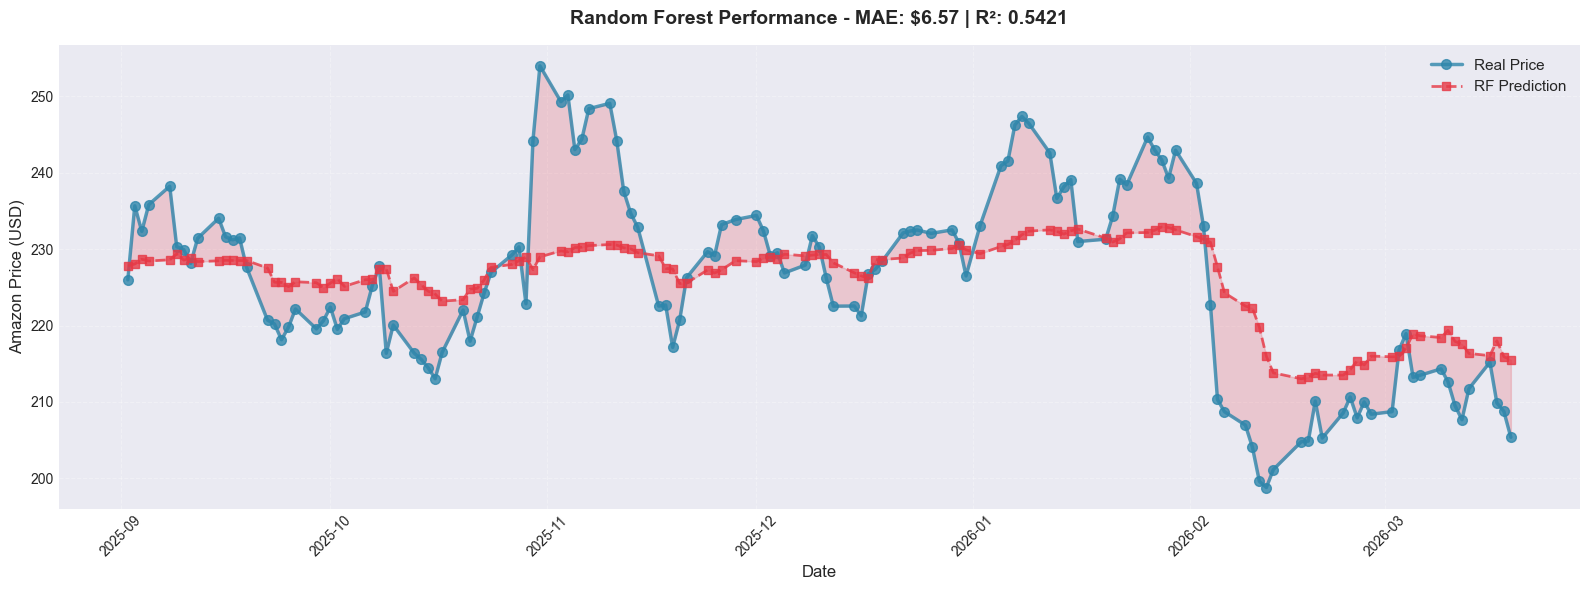

In [11]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1 # all available cores on my M1
)

print("Training RF...")
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest")

# VISUALIZATION

plt.figure(figsize=(16, 6))

plt.plot(test.index, y_test, 'o-', label='Real Price', linewidth=2.5, markersize=7, color='#2E86AB', alpha=0.8)
plt.plot(test.index, y_pred_rf, 's--', label='RF Prediction', linewidth=2, markersize=6, color='#E63946', alpha=0.8)

plt.fill_between(test.index, y_test, y_pred_rf, alpha=0.2, color='#E63946')

plt.title(f'Random Forest Performance - MAE: ${rf_results["mae"]:.2f} | R²: {rf_results["r2"]:.4f}', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amazon Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## XGBOOST

Training ...

 XGBoost Results:
   - MAE:   $5.16
   - RMSE:  $7.10
   - MAPE:  2.22%
   - R²:    0.6693



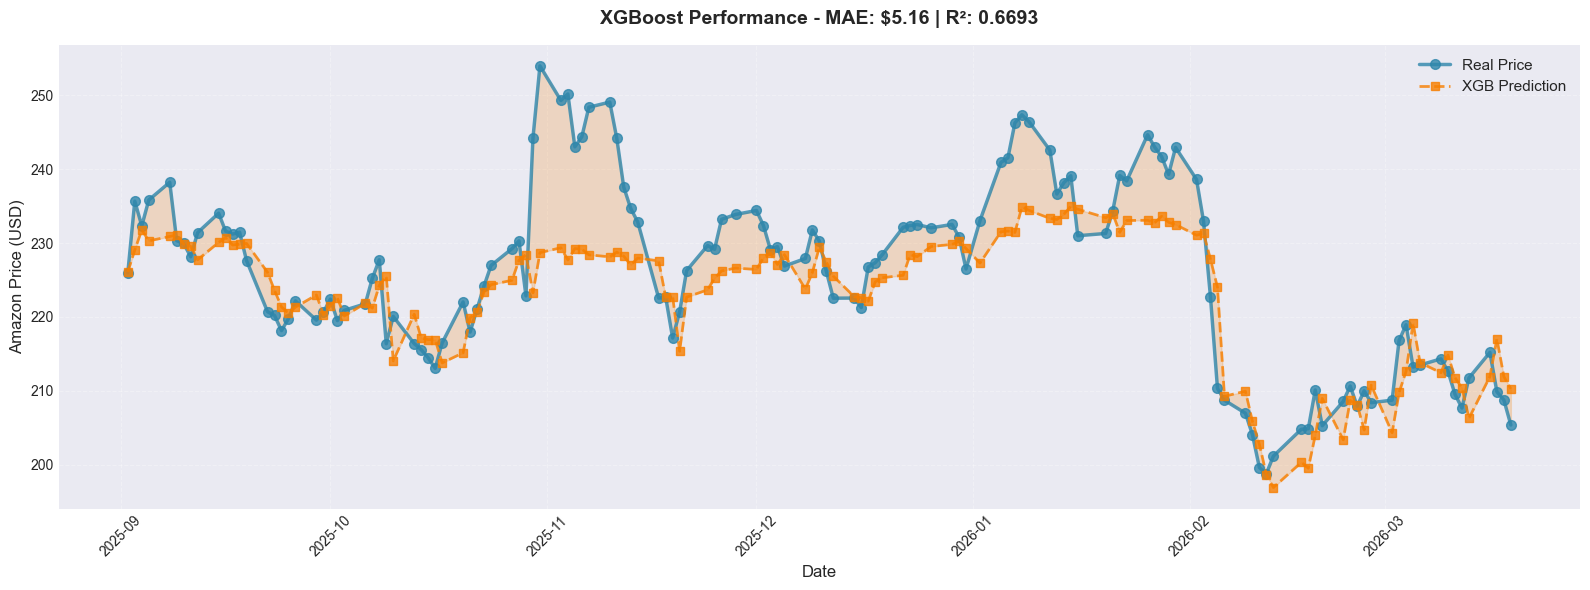

In [12]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1 # all available cores on my M1
)

print("Training ...")
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)


xgb_results = evaluate_model(y_test, y_pred_xgb, "XGBoost")

# VISUALIZATION
plt.figure(figsize=(16, 6))

plt.plot(test.index, y_test, 'o-', label='Real Price', linewidth=2.5, markersize=7, color='#2E86AB', alpha=0.8)
plt.plot(test.index, y_pred_xgb, 's--', label='XGB Prediction', linewidth=2, markersize=6, color='#F77F00', alpha=0.8)

plt.fill_between(test.index, y_test, y_pred_xgb, alpha=0.2, color='#F77F00')

plt.title(f'XGBoost Performance - MAE: ${xgb_results["mae"]:.2f} | R²: {xgb_results["r2"]:.4f}', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amazon Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## SVR

Training ...

 SVR Results:
   - MAE:   $3.80
   - RMSE:  $4.98
   - MAPE:  1.67%
   - R²:    0.8373



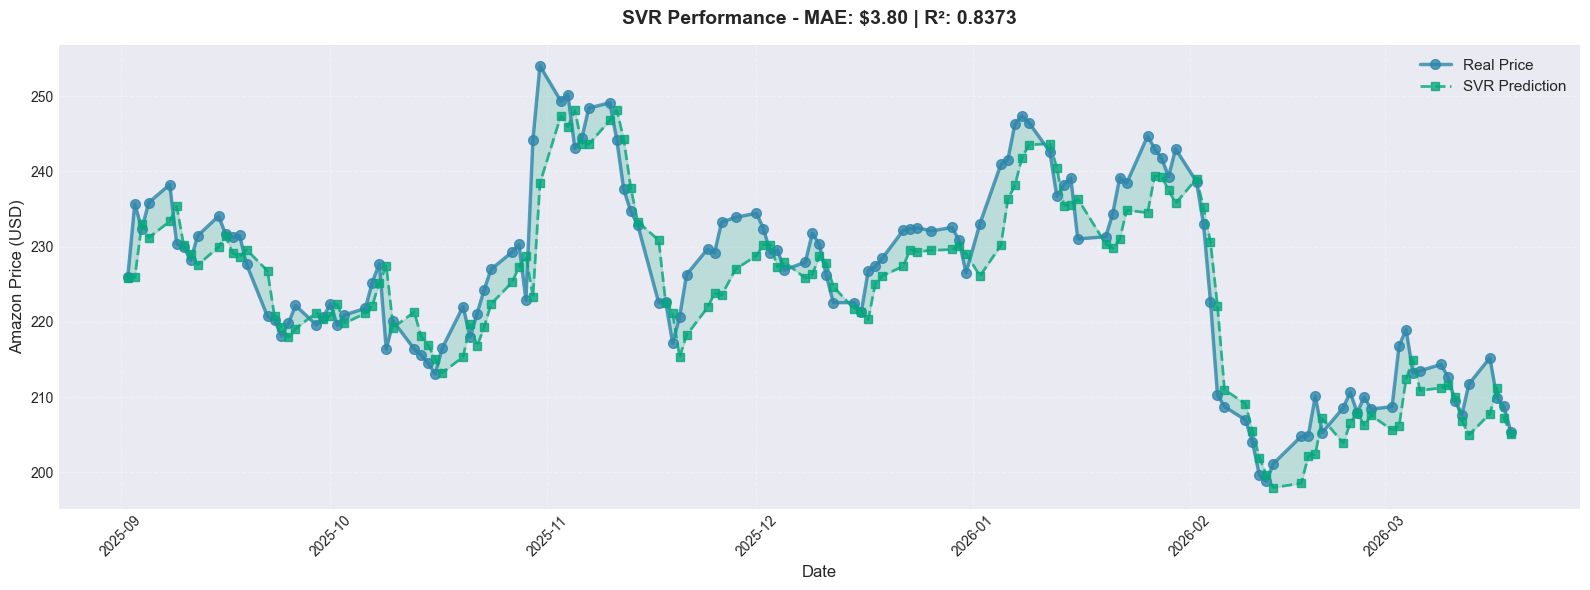

In [13]:
svr_model = SVR(
    kernel='linear', # for high-dimensional feature spaces
    C=1.0,
    epsilon=0.1
)

print("Training ...")
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

svr_results = evaluate_model(y_test, y_pred_svr, "SVR")

# VISUALIZATION
plt.figure(figsize=(16, 6))

plt.plot(test.index, y_test, 'o-', label='Real Price', linewidth=2.5, markersize=7, color='#2E86AB', alpha=0.8)
plt.plot(test.index, y_pred_svr, 's--', label='SVR Prediction', linewidth=2, markersize=6, color='#06A77D', alpha=0.8)

plt.fill_between(test.index, y_test, y_pred_svr, alpha=0.2, color='#06A77D')

plt.title(f'SVR Performance - MAE: ${svr_results["mae"]:.2f} | R²: {svr_results["r2"]:.4f}', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amazon Price (USD)', fontsize=12)
plt.legend(loc='best', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Final Model Comparison and Performance Evaluation


 MODEL PERFORMANCE SUMMARY
         Model      MAE     RMSE  MAPE (%)  R2 Score
           SVR 3.804789 4.977362  1.668778  0.837350
Custom LR (GD) 4.015765 5.154967  1.768537  0.825535
       XGBoost 5.156625 7.097495  2.224192  0.669276
 Random Forest 6.566253 8.351690  2.907384  0.542064

BEST PERFORMING MODEL: SVR
   MAE:  $3.80
   RMSE: $4.98
   R2:   0.8373


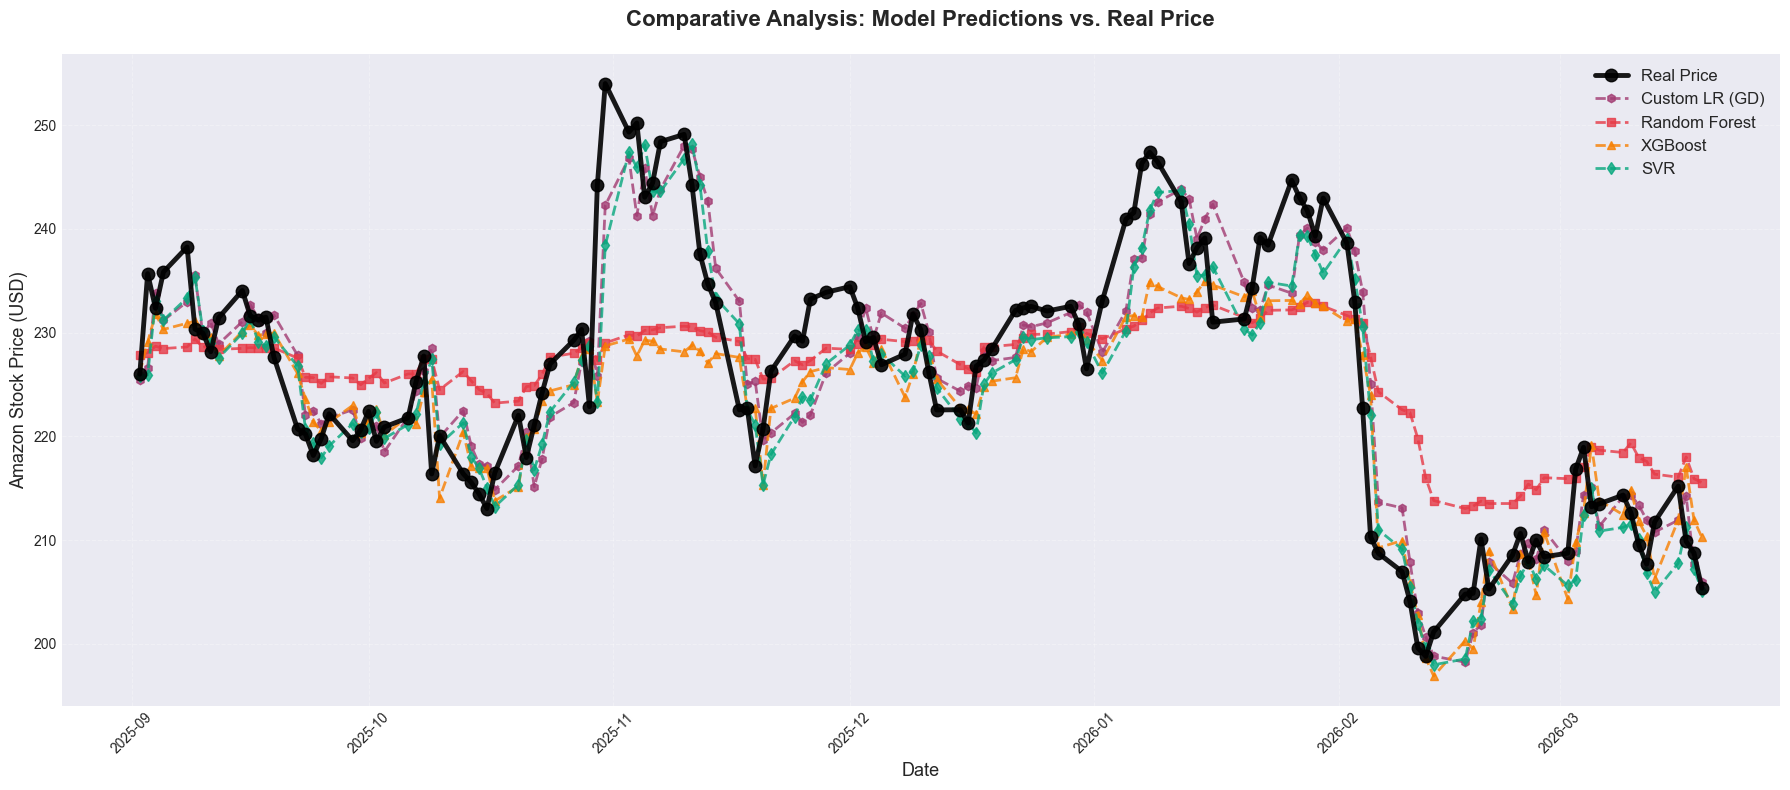

In [14]:
comparison_df = pd.DataFrame({
    'Model': ['Custom LR (GD)', 'Random Forest', 'XGBoost', 'SVR'],
    'MAE': [mae, rf_results['mae'], xgb_results['mae'], svr_results['mae']],
    'RMSE': [rmse, rf_results['rmse'], xgb_results['rmse'], svr_results['rmse']],
    'MAPE (%)': [
        (np.mean(np.abs((y_test - y_pred_gd) / y_test)) * 100), 
        rf_results['mape'], 
        xgb_results['mape'], 
        svr_results['mape']
    ],
    'R2 Score': [r2, rf_results['r2'], xgb_results['r2'], svr_results['r2']]
}).sort_values('RMSE')

print("\n MODEL PERFORMANCE SUMMARY")
print(comparison_df.to_string(index=False))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBEST PERFORMING MODEL: {best_model_name}")
print(f"   MAE:  ${comparison_df.iloc[0]['MAE']:.2f}")
print(f"   RMSE: ${comparison_df.iloc[0]['RMSE']:.2f}")
print(f"   R2:   {comparison_df.iloc[0]['R2 Score']:.4f}")

# VISUALIZATION

plt.figure(figsize=(18, 8))

plt.plot(test.index, y_test, 'o-', label='Real Price', linewidth=3.5, markersize=9, color='black', alpha=0.9, zorder=10)

plt.plot(test.index, y_pred_gd, 'h--', label='Custom LR (GD)', linewidth=2, markersize=6, color='#A23B72', alpha=0.8)
plt.plot(test.index, y_pred_rf, 's--', label='Random Forest', linewidth=2, markersize=6, color='#E63946', alpha=0.8)
plt.plot(test.index, y_pred_xgb, '^--', label='XGBoost', linewidth=2, markersize=6, color='#F77F00', alpha=0.8)
plt.plot(test.index, y_pred_svr, 'd--', label='SVR', linewidth=2, markersize=6, color='#06A77D', alpha=0.8)

plt.title('Comparative Analysis: Model Predictions vs. Real Price', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Amazon Stock Price (USD)', fontsize=13)
plt.legend(loc='best', fontsize=12, framealpha=0.95, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Model Performance Metrics Comparison

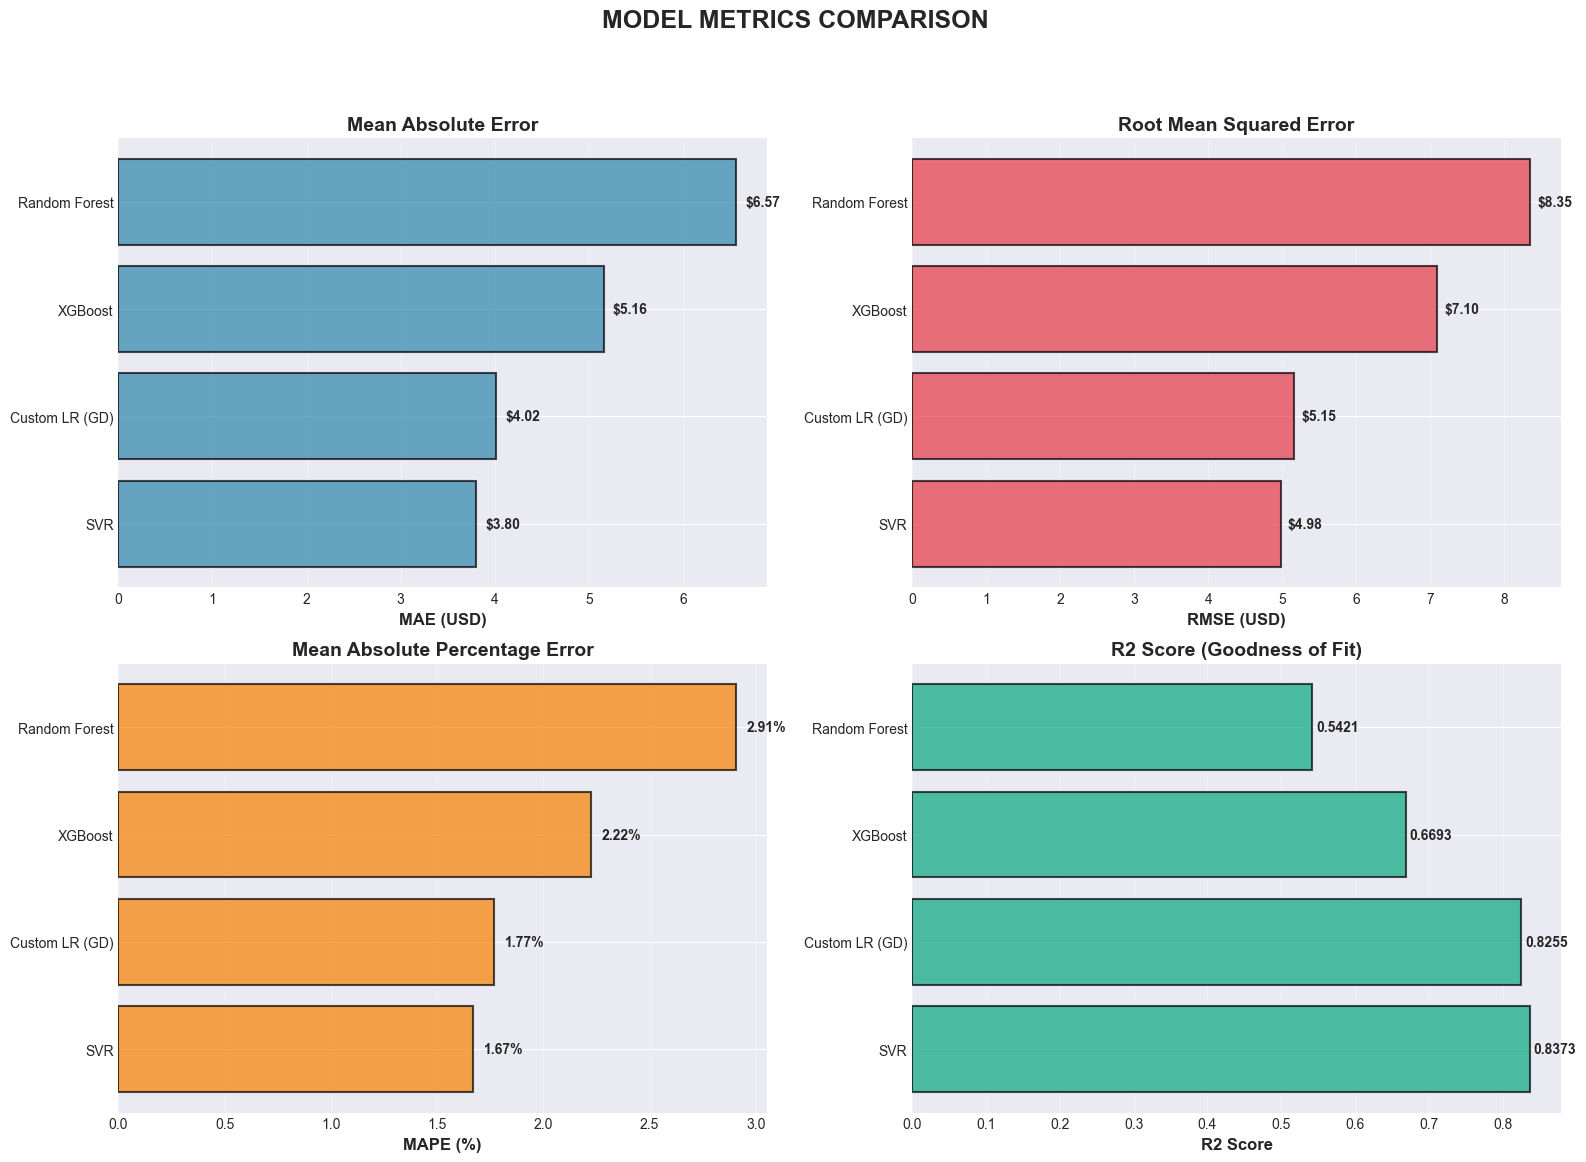

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('MODEL METRICS COMPARISON', fontsize=18, fontweight='bold', y=0.995)

# MAE
axes[0, 0].barh(comparison_df['Model'], comparison_df['MAE'], color='#2E86AB', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 0].set_xlabel('MAE (USD)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['MAE']):
    axes[0, 0].text(v + 0.1, i, f'${v:.2f}', va='center', fontweight='bold')

# RMSE
axes[0, 1].barh(comparison_df['Model'], comparison_df['RMSE'], color='#E63946', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0, 1].set_xlabel('RMSE (USD)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Root Mean Squared Error', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['RMSE']):
    axes[0, 1].text(v + 0.1, i, f'${v:.2f}', va='center', fontweight='bold')

# MAPE
axes[1, 0].barh(comparison_df['Model'], comparison_df['MAPE (%)'], color='#F77F00', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 0].set_xlabel('MAPE (%)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comparison_df['MAPE (%)']):
    axes[1, 0].text(v + 0.05, i, f'{v:.2f}%', va='center', fontweight='bold')

# R2 Score
comp_r2 = comparison_df.sort_values('R2 Score', ascending=False)
axes[1, 1].barh(comp_r2['Model'], comp_r2['R2 Score'], color='#06A77D', alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 1].set_xlabel('R2 Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('R2 Score (Goodness of Fit)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(comp_r2['R2 Score']):
    axes[1, 1].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Final Project Conclusions

### Key Findings
The evaluation shows that **Support Vector Regressor (SVR)** and the **Custom Linear Regression** are the most effective models for predicting Amazon's stock price in this dataset.

* **Linear Trends:** Both SVR and the custom Gradient Descent implementation outperformed ensemble methods (XGBoost/Random Forest), indicating that technical indicators and lags captured strong linear momentum during the test period.
* **Accuracy:** The SVR model achieved a **MAPE of 1.67%** and an **R² of 0.8373**, maintaining an average error of only **$3.81 USD**.
* **Validation:** The custom implementation performed nearly as well as the specialized libraries, validating the underlying mathematical logic of the optimization process.

### Future Work
* **Sentiment Analysis:** Integrating NLP for financial news to capture non-linear market shifts.
* **Deep Learning:** Implementing LSTMs to evaluate long-term temporal dependencies.
* **Optimization:** Fine-tuning XGBoost/Random Forest parameters via Bayesian search.

---
**Project developed by Gabriel RODRIGUEZ POSTIGO - Computer Science**